In [1]:
from src.Elements import Elements
from torchview import draw_graph
import graphviz 
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from src.models import VisionTransformer, VisionTransformerCNN, LT_VisionTransformer, XRFClassifier, ResNet1D, select_model

device = "cuda" if torch.cuda.is_available() else "cpu"



# model = select_model("LT_VisionTransformer", device=device)
# model = select_model("LT_VisionTransformer", device=device)
# model = select_model("VisionTransformerCNN", device=device)
# model = select_model("XRFNet4096", device=device)
model = select_model("XRFClassifier", device=device)

model.to(device)

print(model)

print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

LT_VisionTransformer(
  (patch_embed): Conv1d(1, 256, kernel_size=(128,), stride=(128,), bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
  (standard_blocks): ModuleList(
    (0-4): 5 x TransformerBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): TransformerMLP(
        (feedforward): Sequential(
          (0): LazyLinear(in_features=0, out_features=1024, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): LazyLinear(in_features=0, out_features=256, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (lt_blocks): ModuleList(
    (0-2): 3 x LT_TransformerBlock(
      (norm1_img): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm1_lbl): LayerNo

In [3]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/training_data/artificial/X.npy")
y = np.load("data/training_data/artificial/y.npy")
y[y>0] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 160)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 160)


In [4]:
from pathlib import Path
from datetime import datetime 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# class CustomLoss(nn.Module):
#     def __init__(self, alpha=0.01):
#         super(CustomLoss, self).__init__()
#         self.alpha = alpha
#         self.mse_criterion = nn.L1Loss()
#         self.bce_criterion = nn.BCELoss()

#     def forward(self, y_pred, x_pred , y_batch, X_batch):
#         x_loss = self.mse_criterion(x_pred, X_batch) * (1 - self.alpha) 
#         y_batch[y_batch > 0] = 1
#         y_loss = self.bce_criterion(y_pred, y_batch) * self.alpha
#         return y_loss + x_loss, x_loss, y_loss
        
# custom_criterion = CustomLoss(0.5)


# train_history, valid_history, best_loss, best_weights = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=custom_criterion, epochs=300, mode="constrained_autoencoder", patience=25)

criterion = nn.BCELoss()
train_history, valid_history, best_loss, best_weights, f1_scores, accuracies, recalls, precisions, jaccard_indices, hamming_losses = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=50, mode="supervised", patience=5)


2025-04-29 22:17:20,352 - INFO - Starting training process (mode: supervised, epochs: 50, patience: 5, threshold: 0.5)
2025-04-29 22:17:20,353 - INFO - --- Epoch 1/50 ---
2025-04-29 22:17:21,003 - INFO -   Batch 10/1407, Loss: 0.4595
2025-04-29 22:17:21,410 - INFO -   Batch 20/1407, Loss: 0.4455
2025-04-29 22:17:21,811 - INFO -   Batch 30/1407, Loss: 0.4398
2025-04-29 22:17:22,224 - INFO -   Batch 40/1407, Loss: 0.4563
2025-04-29 22:17:22,610 - INFO -   Batch 50/1407, Loss: 0.4663
2025-04-29 22:17:23,026 - INFO -   Batch 60/1407, Loss: 0.4504
2025-04-29 22:17:23,472 - INFO -   Batch 70/1407, Loss: 0.4536
2025-04-29 22:17:23,910 - INFO -   Batch 80/1407, Loss: 0.4509
2025-04-29 22:17:24,290 - INFO -   Batch 90/1407, Loss: 0.4590
2025-04-29 22:17:24,727 - INFO -   Batch 100/1407, Loss: 0.4524
2025-04-29 22:17:25,152 - INFO -   Batch 110/1407, Loss: 0.4464
2025-04-29 22:17:25,613 - INFO -   Batch 120/1407, Loss: 0.4516
2025-04-29 22:17:26,006 - INFO -   Batch 130/1407, Loss: 0.4448
2025-0

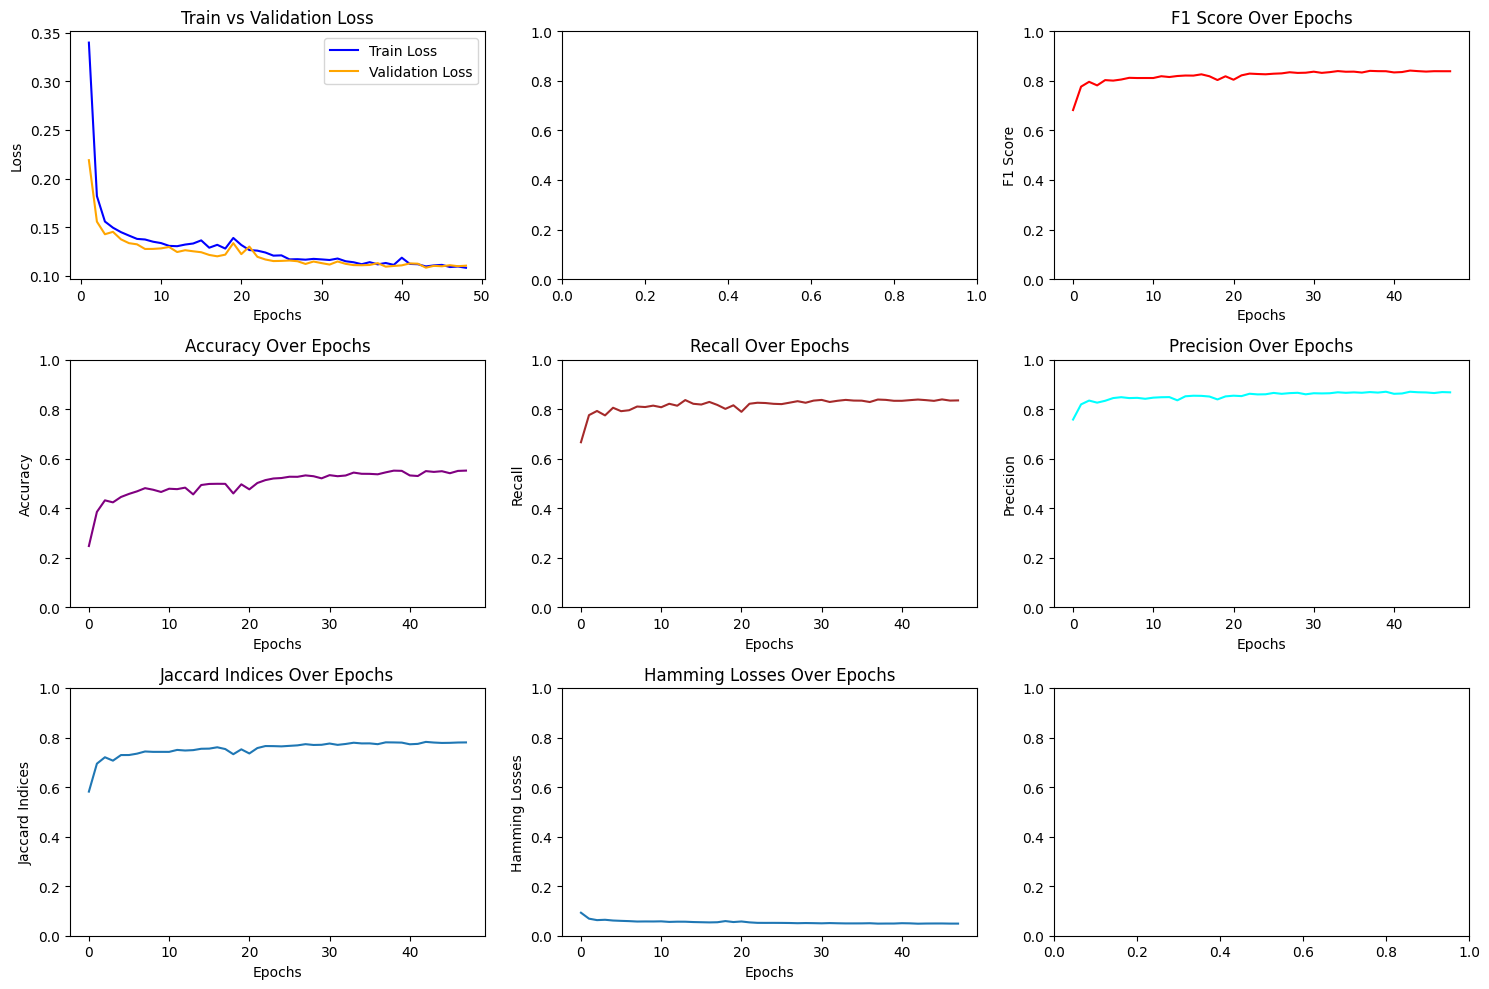

In [5]:
import matplotlib.pyplot as plt 
# Assuming these are lists or arrays representing the values over epochs
epochs = range(1, len(train_history) + 1)  # Assuming length of train_history gives number of epochs

# Create a figure and axes to hold subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 10))

# Plot Train and Validation Loss
axs[0, 0].plot(epochs, train_history, label="Train Loss", color="blue")
axs[0, 0].plot(epochs, valid_history, label="Validation Loss", color="orange")
axs[0, 0].set_title("Train vs Validation Loss")
axs[0, 0].set_xlabel("Epochs")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].legend()

# Plot Best Loss
# axs[0, 1].plot(best_loss, label="Best Loss", color="green")
# axs[0, 1].set_title("Best Loss Over Epochs")
# axs[0, 1].set_xlabel("Epochs")
# axs[0, 1].set_ylabel("Loss")

# Plot F1 Scores
axs[0, 2].plot(f1_scores, label="F1 Score", color="red")
axs[0, 2].set_title("F1 Score Over Epochs")
axs[0, 2].set_xlabel("Epochs")
axs[0, 2].set_ylim(0, 1)
axs[0, 2].set_ylabel("F1 Score")

# Plot Accuracy
axs[1, 0].plot(accuracies, label="Accuracy", color="purple")
axs[1, 0].set_title("Accuracy Over Epochs")
axs[1, 0].set_xlabel("Epochs")
axs[1, 0].set_ylim(0, 1)
axs[1, 0].set_ylabel("Accuracy")

# Plot Recall
axs[1, 1].plot(recalls, label="Recall", color="brown")
axs[1, 1].set_title("Recall Over Epochs")
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].set_ylim(0, 1)
axs[1, 1].set_ylabel("Recall")

# Plot Precision
axs[1, 2].plot(precisions, label="Precision", color="cyan")
axs[1, 2].set_title("Precision Over Epochs")
axs[1, 2].set_xlabel("Epochs")
axs[1, 2].set_ylim(0, 1)
axs[1, 2].set_ylabel("Precision")

axs[2, 0].plot(jaccard_indices, label="Jaccard Indices")
axs[2, 0].set_title("Jaccard Indices Over Epochs")
axs[2, 0].set_xlabel("Epochs")
axs[2, 0].set_ylim(0, 1)
axs[2, 0].set_ylabel("Jaccard Indices")

axs[2, 1].plot(hamming_losses, label="Hamming Losses")
axs[2, 1].set_title("Hamming Losses Over Epochs")
axs[2, 1].set_xlabel("Epochs")
axs[2, 1].set_ylim(0, 1)
axs[2, 1].set_ylabel("Hamming Losses")


# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()


In [6]:
MODEL_NAME = model.__class__.__name__
torch.save(model.state_dict(), Path(f"data/model_weights/{MODEL_NAME}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}"))

In [7]:
aucs, rocs = EvaluationUtils.calculate_roc(model, testloader)

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

def calculate_roc(model, test_loader):
    model.eval()
    all_real, all_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            all_real.append(y_batch.cpu())
            all_pred.append(y_pred.cpu())

    all_real = torch.cat(all_real).numpy()
    all_pred = torch.cat(all_pred).numpy()
    n_classes = all_real.shape[1]
    aucs = {}
    rocs = {}

    for i in range(n_classes):
        symbol = Elements.NUM2SYMBOL[i]
        fpr, tpr, _ = roc_curve(all_real[:, i], all_pred[:, i])
        roc_auc = auc(fpr, tpr)
        aucs[symbol] = roc_auc
        rocs[symbol] = (fpr, tpr)

    return aucs, rocs

aucs, rocs = calculate_roc(model, testloader)

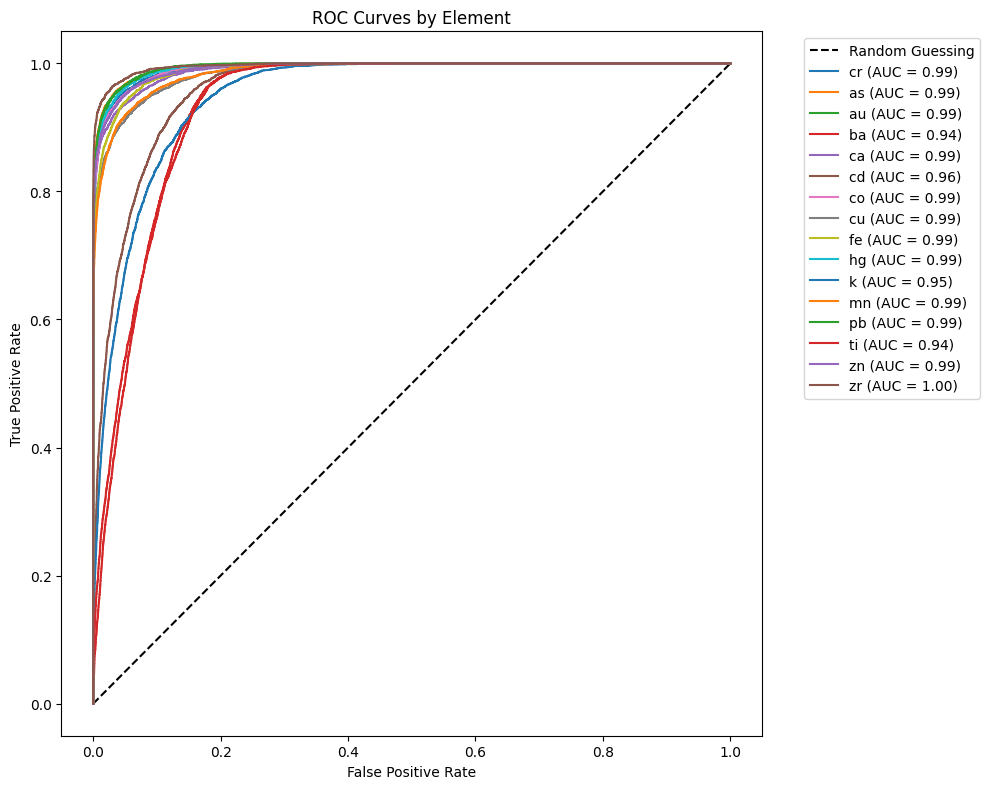

In [9]:


plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
for element_name in Elements.LINES.keys():
    plt.plot(*rocs[element_name], label=f"{element_name} (AUC = {aucs[element_name]:.2f})")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves by Element")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
# plt.savefig("roc_curves.svg")